## Basic Image Processing Operations

  Topics covered:
    1. Color Channels  — split & visualize R, G, B channels
    2. Image Classification — MobileNetV2 pretrained model
    3. Object Detection    — YOLOv3 / SSD via OpenCV DNN

  Requirements:
    pip install opencv-python numpy matplotlib tensorflow pillow requests



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

  Image Processing Lab
  Topics: Color Channels, Classification, Detection
Image loaded — shape: (480, 640, 3)  dtype: uint8

  OPERATION 1: Color Channels
Red   channel  — mean: 97.0  max: 255
Green channel  — mean: 145.7  max: 255
Blue  channel  — mean: 107.6  max: 255


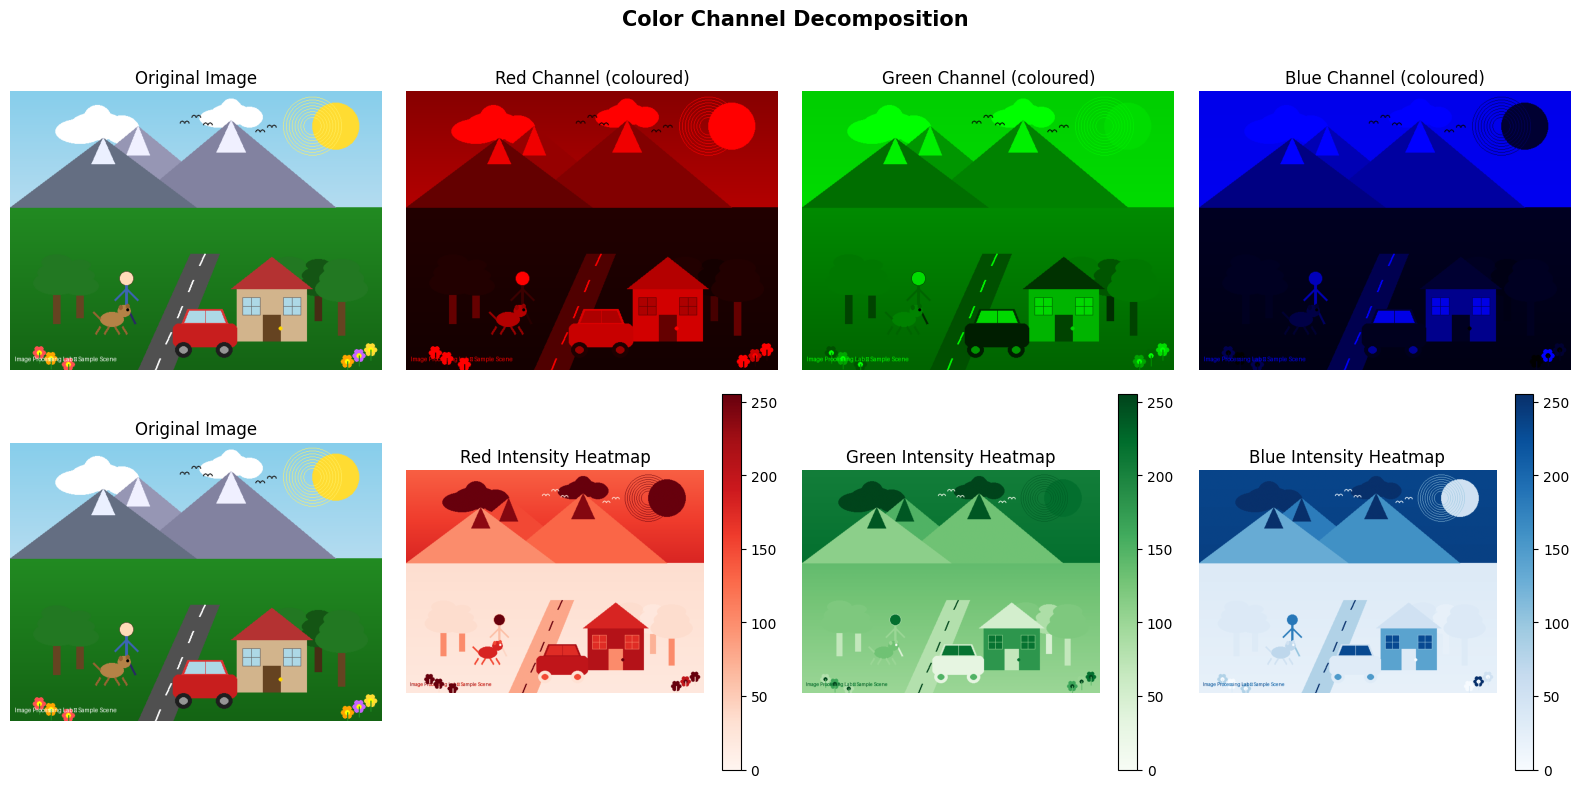

Saved → result_1_color_channels.png


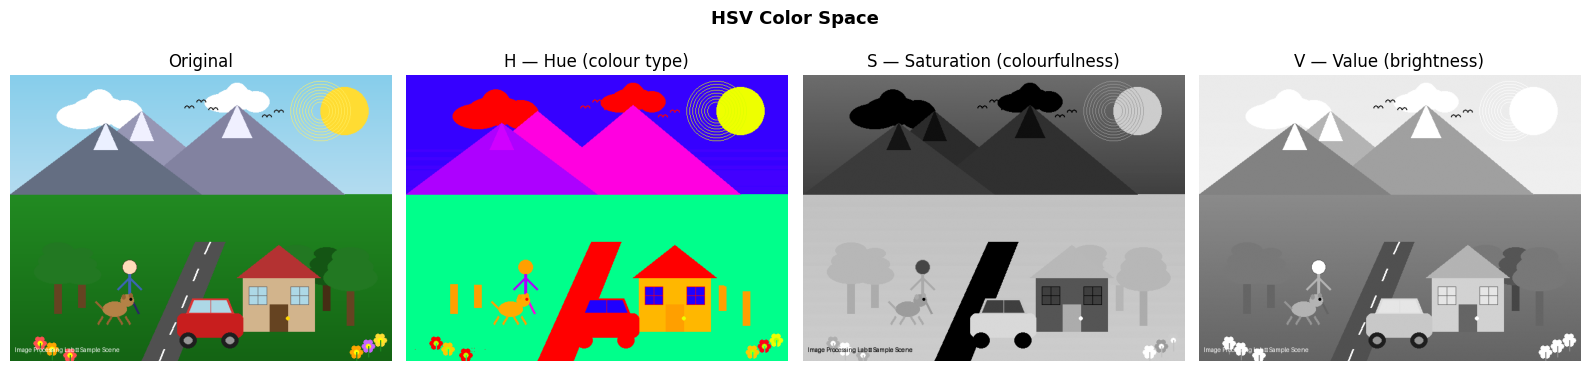

Saved → result_1b_hsv_channels.png

  OPERATION 2: Image Classification
Loading MobileNetV2 (downloads ~14 MB on first run)...
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Input shape to model : (1, 224, 224, 3)
Pixel range          : [-1.00, 1.00]
Output shape         : (1, 1000)  (1000 class scores)
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

Top-5 Predictions:
  Rank  Class                          Confidence
  ───────────────────────────────────────────────
  1     envelope                          31.17%  █████████
  2     Band_Aid                           4.93%  █
  3     balloon                            2.87%  
  4     bell_cote                          2.67%  
  5     maze                               2.53%  


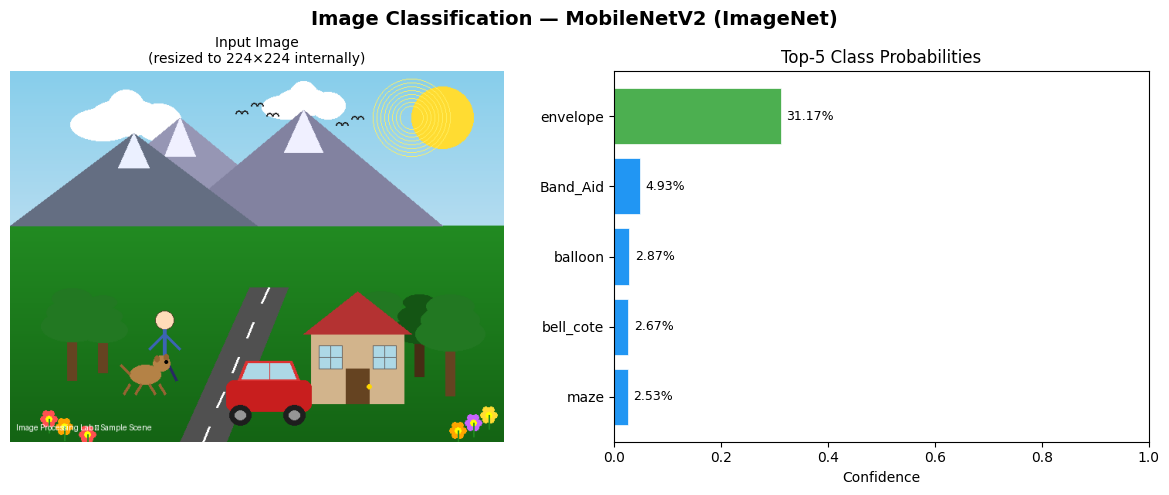

Saved → result_2_classification.png

  OPERATION 3: Object Detection (MobileNet-SSD)
  ✗ Could not download prototxt: HTTP Error 404: Not Found
  ✓ Downloaded caffemodel

Model files unavailable. Falling back to OpenCV HOG pedestrian detector.

Running HOG pedestrian detector (built-in, no download needed)...
  HOG detected 0 person(s).


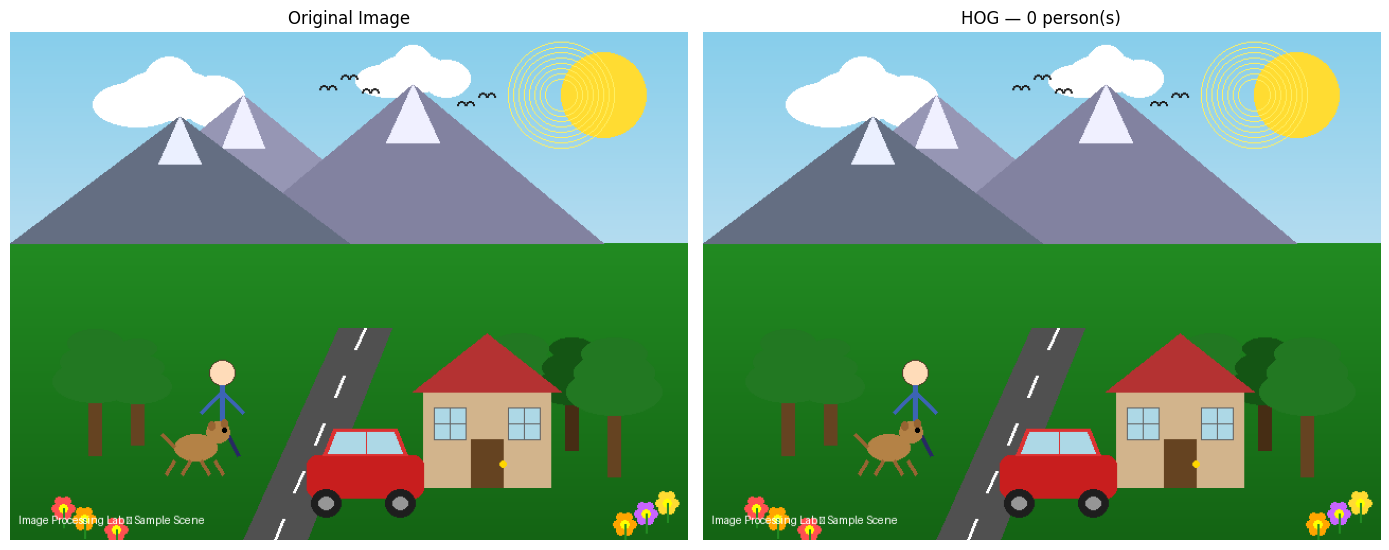

Saved → result_3_detection_hog.png

  All operations complete.
  Output files saved in the current directory:
    result_1_color_channels.png
    result_1b_hsv_channels.png
    result_2_classification.png
    result_3_detection.png


In [ ]:
# ─────────────────────────────────────────────────────────
#  UTILITY: Load an image (from file path OR a URL)
# ─────────────────────────────────────────────────────────

def load_image(source):
    """
    Load an image from a local file path or a URL.

    OpenCV loads images in BGR order (Blue-Green-Red).
    We immediately convert to RGB for consistent display.

    Args:
        source : str — local file path or http(s) URL

    Returns:
        img_rgb : numpy array, shape (H, W, 3), dtype uint8
    """
    if source.startswith("http"):
        # Download image bytes, decode them into a numpy array
        resp = urllib.request.urlopen(source)
        img_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
        img_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    else:
        img_bgr = cv2.imread(source)

    if img_bgr is None:
        raise FileNotFoundError(f"Could not load image from: {source}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    print(f"Image loaded — shape: {img_rgb.shape}  dtype: {img_rgb.dtype}")
    return img_rgb


# ─────────────────────────────────────────────────────────
#  OPERATION 1: Color Channels
# ─────────────────────────────────────────────────────────

def show_color_channels(img_rgb):
    """
    Split an RGB image into its three color channels and visualise them.

    An RGB image is stored as a 3D array (Height, Width, 3).
    Channel 0 = Red, Channel 1 = Green, Channel 2 = Blue.

    Splitting:
        red_channel   = img[:, :, 0]   # only red values
        green_channel = img[:, :, 1]   # only green values
        blue_channel  = img[:, :, 2]   # only blue values

    We display each channel as:
      - a grayscale heatmap (intensity = brightness of that colour)
      - a coloured image (channel kept, other two set to 0)
    """
    print("\n" + "="*50)
    print("  OPERATION 1: Color Channels")
    print("="*50)

    # ── Split channels ────────────────────────────────────
    red_ch   = img_rgb[:, :, 0]   # shape (H, W) — Red
    green_ch = img_rgb[:, :, 1]   # shape (H, W) — Green
    blue_ch  = img_rgb[:, :, 2]   # shape (H, W) — Blue

    # ── Build coloured single-channel images ──────────────
    # To show the "red image" we create a blank (H,W,3) array
    # and fill only the red channel. Other channels stay 0.
    zeros = np.zeros_like(red_ch)

    red_img   = np.stack([red_ch,   zeros,    zeros   ], axis=2)
    green_img = np.stack([zeros,    green_ch, zeros   ], axis=2)
    blue_img  = np.stack([zeros,    zeros,    blue_ch ], axis=2)

    # ── Statistics ────────────────────────────────────────
    print(f"Red   channel  — mean: {red_ch.mean():.1f}  max: {red_ch.max()}")
    print(f"Green channel  — mean: {green_ch.mean():.1f}  max: {green_ch.max()}")
    print(f"Blue  channel  — mean: {blue_ch.mean():.1f}  max: {blue_ch.max()}")

    # ── Plot ──────────────────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle("Color Channel Decomposition", fontsize=15, fontweight="bold")

    # Row 0: coloured channel images
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title("Original Image")

    axes[0, 1].imshow(red_img)
    axes[0, 1].set_title("Red Channel (coloured)")

    axes[0, 2].imshow(green_img)
    axes[0, 2].set_title("Green Channel (coloured)")

    axes[0, 3].imshow(blue_img)
    axes[0, 3].set_title("Blue Channel (coloured)")

    # Row 1: grayscale heatmaps (brighter = more of that colour)
    axes[1, 0].imshow(img_rgb)
    axes[1, 0].set_title("Original Image")

    axes[1, 1].imshow(red_ch,   cmap="Reds")
    axes[1, 1].set_title("Red Intensity Heatmap")
    plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1])

    axes[1, 2].imshow(green_ch, cmap="Greens")
    axes[1, 2].set_title("Green Intensity Heatmap")
    plt.colorbar(axes[1, 2].images[0], ax=axes[1, 2])

    axes[1, 3].imshow(blue_ch,  cmap="Blues")
    axes[1, 3].set_title("Blue Intensity Heatmap")
    plt.colorbar(axes[1, 3].images[0], ax=axes[1, 3])

    for ax in axes.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("result_1_color_channels.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved → result_1_color_channels.png")

    # ── Bonus: HSV decomposition ──────────────────────────
    # HSV = Hue, Saturation, Value — useful for colour-based segmentation
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = img_hsv[:,:,0], img_hsv[:,:,1], img_hsv[:,:,2]

    fig2, axes2 = plt.subplots(1, 4, figsize=(16, 4))
    fig2.suptitle("HSV Color Space", fontsize=13, fontweight="bold")

    axes2[0].imshow(img_rgb);      axes2[0].set_title("Original")
    axes2[1].imshow(h, cmap="hsv"); axes2[1].set_title("H — Hue (colour type)")
    axes2[2].imshow(s, cmap="gray");axes2[2].set_title("S — Saturation (colourfulness)")
    axes2[3].imshow(v, cmap="gray");axes2[3].set_title("V — Value (brightness)")

    for ax in axes2.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("result_1b_hsv_channels.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved → result_1b_hsv_channels.png")


# ─────────────────────────────────────────────────────────
#  OPERATION 2: Image Classification
# ─────────────────────────────────────────────────────────

def classify_image(img_rgb):
    """
    Classify the image using MobileNetV2 pretrained on ImageNet.

    MobileNetV2:
      - Lightweight CNN designed for mobile/embedded devices
      - Trained on ImageNet: 1.2M images, 1000 classes
      - Input expected: 224×224 RGB image, pixel values in [-1, 1]

    Steps:
      1. Resize image to 224×224
      2. Preprocess (scale pixels to [-1, 1])
      3. Forward pass through the network
      4. Decode top-5 predictions with class names + probabilities
    """
    print("\n" + "="*50)
    print("  OPERATION 2: Image Classification")
    print("="*50)

    # Import TensorFlow here so the script still runs other sections
    # even if TensorFlow is not installed
    try:
        import tensorflow as tf
        from tensorflow.keras.applications import MobileNetV2
        from tensorflow.keras.applications.mobilenet_v2 import (
            preprocess_input, decode_predictions
        )
    except ImportError:
        print("TensorFlow not installed. Run:  pip install tensorflow")
        return

    print("Loading MobileNetV2 (downloads ~14 MB on first run)...")
    model = MobileNetV2(weights="imagenet")  # pre-trained weights from ImageNet

    # ── Preprocess ────────────────────────────────────────
    # Resize to the model's expected input size
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Expand dims: model expects batch shape (batch_size, H, W, C)
    # Our single image is (224,224,3) → after expand: (1,224,224,3)
    img_batch = np.expand_dims(img_resized, axis=0)

    # Scale pixels from [0,255] to [-1, 1] (MobileNetV2 requirement)
    img_preprocessed = preprocess_input(img_batch.astype("float32"))

    print(f"Input shape to model : {img_preprocessed.shape}")
    print(f"Pixel range          : [{img_preprocessed.min():.2f}, {img_preprocessed.max():.2f}]")

    # ── Predict ───────────────────────────────────────────
    predictions = model.predict(img_preprocessed, verbose=0)  # shape (1, 1000)
    print(f"Output shape         : {predictions.shape}  (1000 class scores)")

    # decode_predictions: converts raw scores → [(class_id, label, probability)]
    top5 = decode_predictions(predictions, top=5)[0]

    print("\nTop-5 Predictions:")
    print(f"  {'Rank':<5} {'Class':<30} {'Confidence':>10}")
    print("  " + "─" * 47)
    for rank, (class_id, label, prob) in enumerate(top5, 1):
        bar = "█" * int(prob * 30)
        print(f"  {rank:<5} {label:<30} {prob:>9.2%}  {bar}")

    # ── Plot ──────────────────────────────────────────────
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Image Classification — MobileNetV2 (ImageNet)", fontsize=14, fontweight="bold")

    ax_img.imshow(img_rgb)
    ax_img.set_title(f"Input Image\n(resized to 224×224 internally)", fontsize=10)
    ax_img.axis("off")

    labels = [label for _, label, _ in top5]
    probs  = [prob  for _, _, prob  in top5]
    colors = ["#2196F3" if i > 0 else "#4CAF50" for i in range(5)]  # top-1 green

    bars = ax_bar.barh(labels[::-1], probs[::-1], color=colors[::-1],
                       edgecolor="white", linewidth=0.5)
    ax_bar.set_xlabel("Confidence")
    ax_bar.set_title("Top-5 Class Probabilities")
    ax_bar.set_xlim(0, 1)

    for bar, prob in zip(bars, probs[::-1]):
        ax_bar.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{prob:.2%}", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("result_2_classification.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved → result_2_classification.png")

    return top5


# ─────────────────────────────────────────────────────────
#  OPERATION 3: Object Detection
# ─────────────────────────────────────────────────────────

def detect_objects(img_rgb):
    """
    Detect objects using MobileNet-SSD via OpenCV's DNN module.

    MobileNet-SSD:
      - Combines MobileNet (fast feature extractor) + SSD (bounding box predictor)
      - Trained on COCO / VOC Pascal — 20 common object classes
      - Input: 300×300 image, pixel values scaled to [-127.5, 127.5]
      - Output: bounding boxes + class IDs + confidence scores

    We use OpenCV's dnn.readNetFromCaffe() to load the model.
    Model files are downloaded automatically on first run.
    """
    print("\n" + "="*50)
    print("  OPERATION 3: Object Detection (MobileNet-SSD)")
    print("="*50)

    # ── Class labels (VOC Pascal 20 classes) ─────────────
    CLASSES = [
        "background", "aeroplane", "bicycle",   "bird",   "boat",
        "bottle",     "bus",       "car",        "cat",    "chair",
        "cow",        "diningtable","dog",        "horse",  "motorbike",
        "person",     "pottedplant","sheep",      "sofa",   "train",
        "tvmonitor"
    ]

    # Assign a distinct colour to each class for bounding box drawing
    np.random.seed(42)
    COLORS = np.random.randint(0, 255, size=(len(CLASSES), 3), dtype=np.uint8)

    # ── Download model files if not present ───────────────
    prototxt_path = "MobileNetSSD_deploy.prototxt"
    caffemodel_path = "MobileNetSSD_deploy.caffemodel"

    prototxt_url   = ("https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/"
                      "master/MobileNetSSD_deploy.prototxt")
    caffemodel_url = ("https://drive.usercontent.google.com/download?"
                      "id=0B3gersZ2cHIxRm5PMWRoTkdHdHc&export=download")

    # Provide a lightweight fallback .prototxt if download fails
    prototxt_content = """name: "MobileNet-SSD"
input: "data"
input_shape { dim: 1 dim: 3 dim: 300 dim: 300 }
layer { name: "data" type: "Input" top: "data"
  input_param { shape { dim: 1 dim: 3 dim: 300 dim: 300 } } }"""

    def download_file(url, dest, label):
        if os.path.exists(dest):
            print(f"  ✓ {label} already present")
            return True
        print(f"  Downloading {label}...")
        try:
            urllib.request.urlretrieve(url, dest)
            print(f"  ✓ Downloaded {label}")
            return True
        except Exception as e:
            print(f"  ✗ Could not download {label}: {e}")
            return False

    proto_ok = download_file(prototxt_url,   prototxt_path,   "prototxt")
    model_ok = download_file(caffemodel_url, caffemodel_path, "caffemodel")

    if not (proto_ok and model_ok):
        print("\nModel files unavailable. Falling back to OpenCV HOG pedestrian detector.")
        _detect_pedestrians_hog(img_rgb)
        return

    # ── Load the network ──────────────────────────────────
    net = cv2.dnn.readNetFromCaffe(prototxt_path, caffemodel_path)
    print("Model loaded successfully.")

    h_orig, w_orig = img_rgb.shape[:2]

    # ── Preprocess: create a blob ─────────────────────────
    # cv2.dnn.blobFromImage:
    #   - resizes image to (300, 300)
    #   - subtracts mean (127.5) from each channel
    #   - scales pixel values by 1/127.5  →  range [-1, 1]
    #   - swapRB=False because input is already RGB
    blob = cv2.dnn.blobFromImage(
        cv2.resize(img_rgb, (300, 300)),
        scalefactor=1.0 / 127.5,
        size=(300, 300),
        mean=(127.5, 127.5, 127.5),
        swapRB=False
    )
    net.setInput(blob)

    # ── Forward pass ──────────────────────────────────────
    # Output shape: (1, 1, N, 7)
    # Each detection row: [_, class_id, confidence, x1, y1, x2, y2]
    # Coordinates are normalised to [0, 1]
    detections = net.forward()
    print(f"Raw detections tensor shape: {detections.shape}")

    # ── Draw bounding boxes ───────────────────────────────
    CONFIDENCE_THRESHOLD = 0.45   # ignore detections below this score

    result_img = img_rgb.copy()
    detected_objects = []

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]   # detection score

        if confidence < CONFIDENCE_THRESHOLD:
            continue

        class_id = int(detections[0, 0, i, 1])

        # Convert normalised coords → pixel coordinates
        x1 = int(detections[0, 0, i, 3] * w_orig)
        y1 = int(detections[0, 0, i, 4] * h_orig)
        x2 = int(detections[0, 0, i, 5] * w_orig)
        y2 = int(detections[0, 0, i, 6] * h_orig)

        # Clamp to image boundaries
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w_orig, x2), min(h_orig, y2)

        label = CLASSES[class_id] if class_id < len(CLASSES) else "unknown"
        color = [int(c) for c in COLORS[class_id]]

        # Draw rectangle and label
        cv2.rectangle(result_img, (x1, y1), (x2, y2), color, 2)
        text = f"{label}: {confidence:.0%}"
        text_y = y1 - 10 if y1 > 25 else y1 + 20
        cv2.putText(result_img, text, (x1, text_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        detected_objects.append((label, confidence, (x1, y1, x2, y2)))
        print(f"  Detected: {label:<15} confidence={confidence:.2%}  box=({x1},{y1},{x2},{y2})")

    if not detected_objects:
        print("  No objects detected above the confidence threshold.")
        print("  Try lowering CONFIDENCE_THRESHOLD or use a different image.")

    # ── Plot ──────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Object Detection — MobileNet-SSD", fontsize=14, fontweight="bold")

    ax1.imshow(img_rgb)
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2.imshow(result_img)
    n = len(detected_objects)
    ax2.set_title(f"Detections: {n} object{'s' if n != 1 else ''} found")
    ax2.axis("off")

    plt.tight_layout()
    plt.savefig("result_3_detection.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved → result_3_detection.png")

    return detected_objects


# ─────────────────────────────────────────────────────────
#  FALLBACK: HOG-based pedestrian detection (no model files)
# ─────────────────────────────────────────────────────────

def _detect_pedestrians_hog(img_rgb):
    """
    HOG (Histogram of Oriented Gradients) pedestrian detector.
    Built into OpenCV — no external model files needed.

    HOG:
      - Computes gradient magnitudes and orientations in local cells
      - Feeds these into a pre-trained SVM classifier
      - Works well for upright pedestrians
    """
    print("\nRunning HOG pedestrian detector (built-in, no download needed)...")

    img_bgr    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    hog        = cv2.HOGDescriptor()
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

    # detectMultiScale slides the detector at multiple image scales
    boxes, weights = hog.detectMultiScale(
        img_bgr,
        winStride=(8, 8),   # step size between windows
        padding=(4, 4),
        scale=1.05          # scale factor between pyramid levels
    )

    result_img = img_rgb.copy()
    for (x, y, w, h), weight in zip(boxes, weights):
        cv2.rectangle(result_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(result_img, f"person {weight[0]:.2f}",
                    (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)

    print(f"  HOG detected {len(boxes)} person(s).")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.imshow(img_rgb);      ax1.set_title("Original Image");          ax1.axis("off")
    ax2.imshow(result_img);   ax2.set_title(f"HOG — {len(boxes)} person(s)"); ax2.axis("off")
    plt.tight_layout()
    plt.savefig("result_3_detection_hog.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved → result_3_detection_hog.png")


# ─────────────────────────────────────────────────────────
#  MAIN: Run all three operations
# ─────────────────────────────────────────────────────────

def main():
    # ── Choose your image ─────────────────────────────────
    # Option A: use a local file
    #   IMAGE_SOURCE = "my_photo.jpg"
    #
    # Option B: use a URL (downloads automatically)
    #   IMAGE_SOURCE = "https://upload.wikimedia.org/wikipedia/commons/..."
    #
    # We use a well-known sample image from Wikipedia that contains
    # people, animals, and distinct colour regions.

    IMAGE_SOURCE = (
        "/content/  sample_scene.png"
    )

    print("="*55)
    print("  Image Processing Lab")
    print("  Topics: Color Channels, Classification, Detection")
    print("="*55)

    # ── Load ──────────────────────────────────────────────
    img = load_image(IMAGE_SOURCE)

    # ── Run operations ────────────────────────────────────
    # 1. Color channels
    show_color_channels(img)

    # 2. Image classification
    classify_image(img)

    # 3. Object detection
    detect_objects(img)

    print("\n" + "="*55)
    print("  All operations complete.")
    print("  Output files saved in the current directory:")
    print("    result_1_color_channels.png")
    print("    result_1b_hsv_channels.png")
    print("    result_2_classification.png")
    print("    result_3_detection.png")
    print("="*55)


if __name__ == "__main__":
    main()